# Desafio Técnico - Gato Mestre (Ciência de Dados)
## Notebook 04: Modelagem de Machine Learning, Validação Temporal e Evolução Algorítmica

### 🎯 Objetivo do Notebook
Construir uma narrativa evolutiva de Machine Learning para estimar a pontuação esperada (`pontos_num`) para **toda a base de atletas cadastrados no Cartola FC (115.613 registros)**, sem nenhum filtro de exclusão ou viés de sobrevivência.

> **1. Baseline Heurístico (Média)** &rarr; **2. Modelos Paramétricos (OLS e Ridge)** &rarr; **3. Modelos Não-Lineares (Árvores e GBDT)**

---
### 💡 Racional de Negócio: Por Que Prever para Toda a Base?

1. **Ambiente Real de Produção:** No momento em que o mercado fecha, o usuário ou o sistema de recomendação precisa avaliar todos os atletas disponíveis no mercado, inclusive aqueles com status duvidoso ou reservas.
2. **Capacidade dos Modelos de Aprender o Risco de Não Jogar:** Os modelos utilizam variáveis preditoras pré-jogo (`status_pre`, `status_inicial`, `taxa_participacao_3j`, `minutos_medios_3j`, `score_risco_rotacao`) para **atribuir nota próxima de zero** a jogadores não relacionados ou lesionados, e pontuação real de performance aos atletas titulares e prováveis.

### 1. Importação das Bibliotecas, Semente de Reprodutibilidade e Carga dos Dados

In [10]:
from pathlib import Path
from IPython.display import display
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import joblib

# Semente Global para 100% de Reprodutibilidade Científica
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

# Pré-processamento e Modelos Lineares
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge

# Modelos baseados em Árvores e Ensembles
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Métricas de Avaliação
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Tabelas interativas
import itables
from itables import init_notebook_mode, show

# Configurações estéticas
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

init_notebook_mode(all_interactive=True)
itables.options.maxBytes = 0
itables.options.classes = ["display", "nowrap"]
itables.options.lengthMenu = [10, 25, 50]

# Definição de caminhos
PROJECT_ROOT = Path("..").resolve() if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Carga da matriz final de features gerada no Notebook 03 (Base Completa: 115.613 linhas)
df_features = pd.read_parquet(DATA_PROCESSED_DIR / "base_features_gm.parquet")
print(f"Matriz de Features carregada: {df_features.shape[0]:,} linhas x {df_features.shape[1]} colunas")
print(f"Total de valores nulos: {df_features.isna().sum().sum()} (100% íntegra)")
print(f"Semente Global Ativa: {GLOBAL_SEED}")

Matriz de Features carregada: 115,613 linhas x 70 colunas
Total de valores nulos: 0 (100% íntegra)
Semente Global Ativa: 42


### 2. Estratégia de Validação Temporal Estrita (*Out-of-Time Validation*)

A divisão temporal abrange **todos os atletas** cadastrados em cada temporada de 2022 a 2025:
* **Treino (Safras 2022 e 2023):** $59.213$ registros para calibrar os modelos nos dados históricos.
* **Validação (Safra 2024):** $28.568$ registros para ajuste fino de hiperparâmetros.
* **Teste / Out-of-Sample OOS (Safra 2025):** $27.832$ registros para avaliação cega de generalização em toda a base.

=== DISTRIBUIÇÃO TEMPORAL DA BASE COMPLETA (TODOS OS ATLETAS) ===


Safra / Partição  Total Registros  Proporção (%)  Atletas que Jogaram  \
0  Treino (2022 + 2023)            59213        51.2170                24418   
1      Validação (2024)            28568        24.7100                12251   
2      Teste OOS (2025)            27832        24.0730                11812   
3           Total Geral           115613       100.0000                48481   

   Taxa que Entrou (%)  Média Pontos  
0              41.2380        1.3060  
1              42.8840        1.3420  
2              42.4400        1.5050  
3              41.9340        1.3630

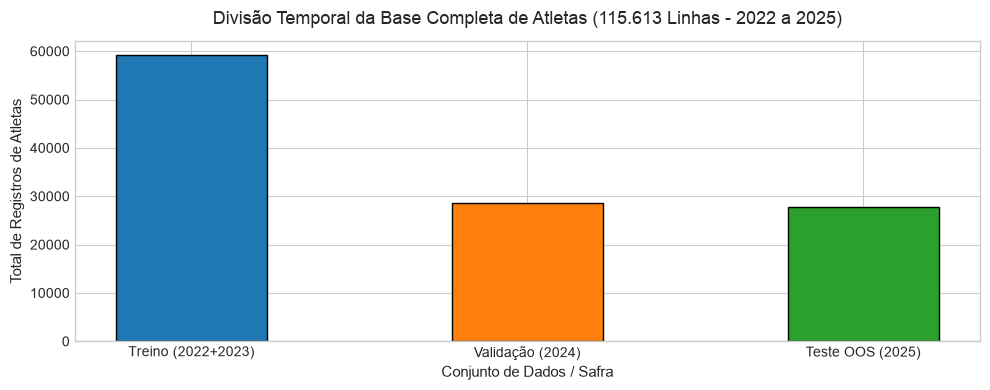

In [2]:
# Divisão temporal por safras anuais completas (Toda a base de 115.613 registros)
train_mask = df_features["ano"].isin([2022, 2023])
val_mask = df_features["ano"] == 2024
test_mask = df_features["ano"] == 2025

print("=== DISTRIBUIÇÃO TEMPORAL DA BASE COMPLETA (TODOS OS ATLETAS) ===")
resumo_splits = pd.DataFrame({
    "Safra / Partição": ["Treino (2022 + 2023)", "Validação (2024)", "Teste OOS (2025)", "Total Geral"],
    "Total Registros": [train_mask.sum(), val_mask.sum(), test_mask.sum(), len(df_features)],
    "Proporção (%)": [
        (train_mask.sum() / len(df_features)) * 100,
        (val_mask.sum() / len(df_features)) * 100,
        (test_mask.sum() / len(df_features)) * 100,
        100.0
    ],
    "Atletas que Jogaram": [
        df_features.loc[train_mask, "entrou_em_campo"].sum(),
        df_features.loc[val_mask, "entrou_em_campo"].sum(),
        df_features.loc[test_mask, "entrou_em_campo"].sum(),
        df_features["entrou_em_campo"].sum()
    ],
    "Taxa que Entrou (%)": [
        df_features.loc[train_mask, "entrou_em_campo"].mean() * 100,
        df_features.loc[val_mask, "entrou_em_campo"].mean() * 100,
        df_features.loc[test_mask, "entrou_em_campo"].mean() * 100,
        df_features["entrou_em_campo"].mean() * 100
    ],
    "Média Pontos": [
        df_features.loc[train_mask, "pontos_num"].mean(),
        df_features.loc[val_mask, "pontos_num"].mean(),
        df_features.loc[test_mask, "pontos_num"].mean(),
        df_features["pontos_num"].mean()
    ]
})
display(resumo_splits.round(3))

# Visualização da Partição Temporal Completa
plt.figure(figsize=(10, 4))
plt.bar(["Treino (2022+2023)", "Validação (2024)", "Teste OOS (2025)"],
        [train_mask.sum(), val_mask.sum(), test_mask.sum()],
        color=["#1f77b4", "#ff7f0e", "#2ca02c"], edgecolor="black", width=0.45)
plt.title("Divisão Temporal da Base Completa de Atletas (115.613 Linhas - 2022 a 2025)", fontsize=13, pad=12)
plt.xlabel("Conjunto de Dados / Safra", fontsize=11)
plt.ylabel("Total de Registros de Atletas", fontsize=11)
plt.tight_layout()
plt.show()

### 3. Modelos Lineares Paramétricos (OLS e Ridge $L_2$)

#### Racional de Seleção de Features e Prevenção Estrita a *Data Leakage*
A matriz bruta `df_features` contém 70 colunas, mas a modelagem utiliza estritamente as **37 variáveis preditoras pré-jogo (`feature_cols_all`)**. Esta separação é vital por razões conceituais e metodológicas:

1. **Variável Alvo (*Target*):** `pontos_num` é a variável de desfecho a ser estimada e é isolada em `y`.
2. **Identificadores e Metadados (Não Preditores):** `atleta_id`, `match_id`, `ano`, `apelido`, `posicao_nome` são mantidos na tabela para rastreabilidade, mas não entram na matriz de pesos.
3. **Scouts e Métricas Pós-Jogo (PROIBIDOS no Instante $t$):** `minutos_jogados`, `entrou_em_campo`, `G`, `A`, `SG`, `DS`, `FS`, `FD`, `FF`, `CA`, `CV`, etc. Esses eventos só acontecem durante os 90 minutos de jogo. Incluí-los diretamente no treino configuraria **vazamento temporal gravíssimo (*Data Leakage*)**. Seus efeitos são capturados de forma legítima através de **médias móveis e defasagens (*lags*)** calculadas no Notebook 03 (`media_scouts_volume_3j`, `taxa_participacao_3j`, `minutos_medios_3j`, etc.).
4. **Campos de mercado e escalação excluídos:** `status_inicial` representa a escalação oficial da rodada e é excluído por revelar informação indisponível no fechamento do mercado. `preco_num`, `media_num`, `jogos_num` e `variacao_num` em $t$ também não entram diretamente; são usados apenas seus equivalentes históricos, como `preco_mercado_pre` e `media_acumulada_pre`.
5. **Conjunto Final de Variáveis Válidas (`feature_cols_all = 37 features`):**
   * **4 Categóricas Nominais:** `posicao_id`, `status_pre`, `clube_id`, `opponent`.
   * **3 Flags Binárias:** `home_dummy`, `is_inicio_temporada`, `participou_lag1`.
   * **30 Numéricas Contínuas:** Médias históricas defasadas, preço e média pré-rodada, métricas de confronto da API, scores de risco e as quatro variáveis Alavanca 2: conversão de gols, diferencial de preço por posição, expectativa de gols do time e potencial de saldo de gols defensivo.

#### Racional do Pré-processamento Linear
Modelos lineares assumem aditividade e são altamente sensíveis a distâncias métricas e correlação entre features:

1. **Categóricas Nominais:** `OneHotEncoder(drop='first', handle_unknown='ignore')` para eliminar a armadilha da variável dummy (*Dummy Variable Trap*).
2. **Numéricas Contínuas:** `StandardScaler()` para centralizar em $\mu = 0$ e variância unitária $\sigma^2 = 1$, equalizando a penalidade da regularização $L_2$ do Ridge.
3. **Flags Binárias:** `passthrough` mantendo os valores originais $\{0, 1\}$.

In [3]:
# 1. Definição das Variáveis Preditoras Válidas Pré-Jogo (ZERO Data Leakage)
cat_cols_linear = ["posicao_id", "status_pre", "clube_id", "opponent"]
bin_cols_linear = ["home_dummy", "is_inicio_temporada", "participou_lag1"]
num_cols_linear = [
    "rodada_id", "clube_media_pontos_conquistados", "opponent_media_pontos_cedidos",
    "progresso_campeonato", "taxa_participacao_3j", "minutos_medios_3j",
    "pontos_lag1", "media_pontos_3j", "desvio_pontos_3j", "media_acumulada_pre",
    "media_scouts_volume_3j", "preco_mercado_pre", "momentum_preco_3j",
    "roi_recente_3j", "estabilidade_11_titular_clube", "fator_alavancagem_confronto",
    "potencial_esperado_atleta", "indice_favoritismo_mando", "volume_esperado_partida",
    "diff_forca_confronto", "score_risco_rotacao", "media_desarmes_3j",
    "media_finalizacoes_3j", "taxa_participacao_gols_5j",
    "score_risco_disciplinar_5j", "taxa_defesas_por_jogo_3j",
    "taxa_conversao_gols_5j", "diff_preco_posicao_pre", "expectativa_gols_time",
    "potencial_sg_defesa"
]

feature_cols_all = cat_cols_linear + num_cols_linear + bin_cols_linear

print(f"Total de Variáveis na Base Carregada: {df_features.shape[1]}")
print(f"Total de Features Preditoras Utilizadas: {len(feature_cols_all)} "
      f"(Categóricas: {len(cat_cols_linear)}, Numéricas: {len(num_cols_linear)}, Binárias: {len(bin_cols_linear)})")
print("Prevenção a Data Leakage: Todas as features são pré-jogo ou defasadas (lags / médias móveis).")

# Pipeline de Pré-processamento Linear (Fit no Treino, Transform em Val/Test)
preprocessor_linear = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), cat_cols_linear),
        ("num", StandardScaler(), num_cols_linear),
        ("bin", "passthrough", bin_cols_linear)
    ]
)

X_train_raw = df_features.loc[train_mask, feature_cols_all]
y_train = df_features.loc[train_mask, "pontos_num"].values

X_val_raw = df_features.loc[val_mask, feature_cols_all]
y_val = df_features.loc[val_mask, "pontos_num"].values

X_test_raw = df_features.loc[test_mask, feature_cols_all]
y_test = df_features.loc[test_mask, "pontos_num"].values

# Transformação estrita
X_train_lin = preprocessor_linear.fit_transform(X_train_raw)
X_val_lin = preprocessor_linear.transform(X_val_raw)
X_test_lin = preprocessor_linear.transform(X_test_raw)

print(f"\nMatriz Linear X_train: {X_train_lin.shape} | y_train: {len(y_train):,}")
print(f"Matriz Linear X_val:   {X_val_lin.shape}   | y_val:   {len(y_val):,}")
print(f"Matriz Linear X_test:  {X_test_lin.shape}  | y_test:  {len(y_test):,}")

# 2. Treinamento dos Modelos Lineares
modelos_lineares = {}

print("\nTreinando Regressão Linear (OLS)...")
ols_model = LinearRegression()
ols_model.fit(X_train_lin, y_train)
modelos_lineares["Regressão Linear (OLS)"] = ols_model

print(f"Treinando Ridge Regression (L2, alpha=10.0, seed={GLOBAL_SEED})...")
ridge_model = Ridge(alpha=10.0, random_state=GLOBAL_SEED)
ridge_model.fit(X_train_lin, y_train)
modelos_lineares["Ridge Regression (L2)"] = ridge_model

print("Modelos lineares treinados com sucesso!")

Total de Variáveis na Base Carregada: 70
Total de Features Preditoras Utilizadas: 37 (Categóricas: 4, Numéricas: 30, Binárias: 3)
Prevenção a Data Leakage: Todas as features são pré-jogo ou defasadas (lags / médias móveis).

Matriz Linear X_train: (59213, 88) | y_train: 59,213
Matriz Linear X_val:   (28568, 88)   | y_val:   28,568
Matriz Linear X_test:  (27832, 88)  | y_test:  27,832

Treinando Regressão Linear (OLS)...
Treinando Ridge Regression (L2, alpha=10.0, seed=42)...
Modelos lineares treinados com sucesso!


### 4. Modelos Baseados em Árvores e Ensembles (*Random Forest, LightGBM, XGBoost, CatBoost*)

#### ⚙️ Racional do Pré-processamento de Árvores
Modelos baseados em árvore particionam o espaço de features através de divisões ortogonais (*threshold splits*):
1. **Variáveis Categóricas:** *Ordinal Encoding* nativo (`.astype('category').cat.codes`), preservando a compacidade da matriz sem inflar a dimensionalidade em colunas dummy esparsas.
2. **Variáveis Numéricas:** Escala natural preservada, pois árvores de decisão são **invariantes a transformações monotônicas de escala** ($f(x) = ax + b$).

In [4]:
def preparar_dados_arvores(df_input, features, categoricas):
    """Prepara matrizes com codificação ordinal nativa para modelos de árvores."""
    df_proc = df_input.copy()
    for col in categoricas:
        df_proc[col] = df_proc[col].astype("category").cat.codes
    return df_proc[features]

X_train_tree = preparar_dados_arvores(df_features[train_mask], feature_cols_all, cat_cols_linear)
X_val_tree = preparar_dados_arvores(df_features[val_mask], feature_cols_all, cat_cols_linear)
X_test_tree = preparar_dados_arvores(df_features[test_mask], feature_cols_all, cat_cols_linear)

modelos_arvores = {}

# 1. Random Forest Regressor
print(f"Treinando Random Forest Regressor (seed={GLOBAL_SEED})...")
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=GLOBAL_SEED,
    n_jobs=-1
)
rf_model.fit(X_train_tree, y_train)
modelos_arvores["Random Forest"] = rf_model

# 2. LightGBM Regressor
print(f"Treinando LightGBM Regressor (seed={GLOBAL_SEED})...")
lgbm_model = LGBMRegressor(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.04,
    num_leaves=31,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=GLOBAL_SEED,
    verbose=-1
)
lgbm_model.fit(X_train_tree, y_train)
modelos_arvores["LightGBM"] = lgbm_model

# 3. XGBoost Regressor
print(f"Treinando XGBoost Regressor (seed={GLOBAL_SEED})...")
xgb_model = XGBRegressor(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.04,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=GLOBAL_SEED,
    n_jobs=-1
)
xgb_model.fit(X_train_tree, y_train)
modelos_arvores["XGBoost"] = xgb_model

# 4. CatBoost Regressor
print(f"Treinando CatBoost Regressor (seed={GLOBAL_SEED})...")
cat_model = CatBoostRegressor(
    iterations=200,
    depth=6,
    learning_rate=0.04,
    l2_leaf_reg=3.0,
    random_seed=GLOBAL_SEED,
    verbose=0
)
cat_model.fit(X_train_tree, y_train)
modelos_arvores["CatBoost"] = cat_model

print("\nTodos os modelos de árvore treinados com sucesso!")

Treinando Random Forest Regressor (seed=42)...
Treinando LightGBM Regressor (seed=42)...
Treinando XGBoost Regressor (seed=42)...
Treinando CatBoost Regressor (seed=42)...

Todos os modelos de árvore treinados com sucesso!


### 5. Comparativo Geral de Performance na Base Completa (Safra 2025 - $N = 27.832$)

Nesta seção, avaliamos todos os modelos no conjunto de Teste Out-of-Sample (Safra 2025). Para analisar a performance sob a ótica da **precisão numérica** e da **capacidade de escalação e ranqueamento**, utilizamos 6 métricas fundamentais:

---

#### Dicionário Matemático e Conceitual das Métricas de Avaliação

1. **MAE (Mean Absolute Error - Erro Médio Absoluto):**
   $$\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|$$
   * **$N$:** Quantidade total de atletas avaliados no conjunto de teste.
   * **$y_i$:** Pontuação real obtida pelo atleta $i$ na rodada.
   * **$\hat{y}_i$:** Pontuação predita pelo modelo para o atleta $i$.
   * **$|y_i - \hat{y}_i|$:** Módulo da diferença (erro linear direto em pontos).
   * **O que mede:** A magnitude média do erro em pontos.

2. **RMSE (Root Mean Squared Error - Raiz do Erro Quadrático Médio):**
   $$\text{RMSE} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}$$
   * **O que mede:** Sensibilidade a grandes falhas de previsão, pois penaliza desproporcionalmente grandes desvios.

3. **$R^2$ (Coeficiente de Determinação):**
   $$R^2 = 1 - \frac{\sum_{i=1}^{N} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{N} (y_i - \mu_y)^2}$$
   * **O que mede:** Percentual da variabilidade dos pontos reais explicado pelo modelo.

4. **Spearman $\rho$ (Correlação de Postos de Spearman - Capacidade de Ranqueamento):**
   $$\rho = 1 - \frac{6 \sum_{i=1}^{N} d_i^2}{N(N^2 - 1)}$$
   * **$d_i = \text{Rank}(y_i) - \text{Rank}(\hat{y}_i)$:** Diferença de posições entre a classificação real e a predita.
   * **O que mede:** A capacidade monotônica de colocar os melhores atletas no topo da lista para escalação.

5. **Pearson $r$ (Coeficiente de Correlação Linear):**
   $$r = \frac{\sum_{i=1}^{N} (y_i - \mu_y)(\hat{y}_i - \mu_{\hat{y}})}{\sqrt{\sum_{i=1}^{N} (y_i - \mu_y)^2} \sqrt{\sum_{i=1}^{N} (\hat{y}_i - \mu_{\hat{y}})^2}}$$
   * **O que mede:** O grau de proporcionalidade linear entre a escala real e a escala predita.

6. **MAE Top 20% (Erro no Grupo Decisivo):**
   $$\text{MAE}_{\text{Top20}} = \frac{1}{|S_{20}|} \sum_{i \in S_{20}} |y_i - \hat{y}_i|$$
   * **$S_{20}$:** Conjunto dos $20\%$ atletas com as maiores pontuações da rodada.
   * **O que mede:** A precisão nos atletas que mais pontuam.

=== PERFORMANCE COMPARATIVA EM TODA A BASE DE ATLETAS (TESTE 2025: N = 27.832) ===


Família                             Modelo  MAE (Geral)  \
4  2. Árvores / Ensembles                           LightGBM       1.4103   
5  2. Árvores / Ensembles                            XGBoost       1.4134   
6  2. Árvores / Ensembles                           CatBoost       1.4199   
3  2. Árvores / Ensembles                      Random Forest       1.4346   
1   1. Linear Paramétrico             Regressão Linear (OLS)       1.4754   
2   1. Linear Paramétrico              Ridge Regression (L2)       1.4758   
0           0. Heurística  0. Baseline (media_acumulada_pre)       2.2299   

    RMSE      R²  Spearman (rho)  Pearson (r)  MAE Top 20%  \
4 2.5152  0.3451          0.6011       0.5928       3.5987   
5 2.5194  0.3430          0.6008       0.5915       3.6055   
6 2.5186  0.3433          0.6004       0.5940       3.6108   
3 2.5332  0.3357          0.5976       0.5819       3.5599   
1 2.5499  0.3269          0.5921       0.5818       3.6825   
2 2.5498  0.3270          0.5921       0.5819       3.6810   
0 3.3032 -0.1295          0.3799       0.3446       3.5373   

   Redução MAE vs Baseline (%)  
4                      36.7544  
5                      36.6158  
6                      36.3260  
3                      35.6639  
1                      33.8370  
2                      33.8160  
0                       0.0000

findfont: Failed to find font weight semibold, now using 700.


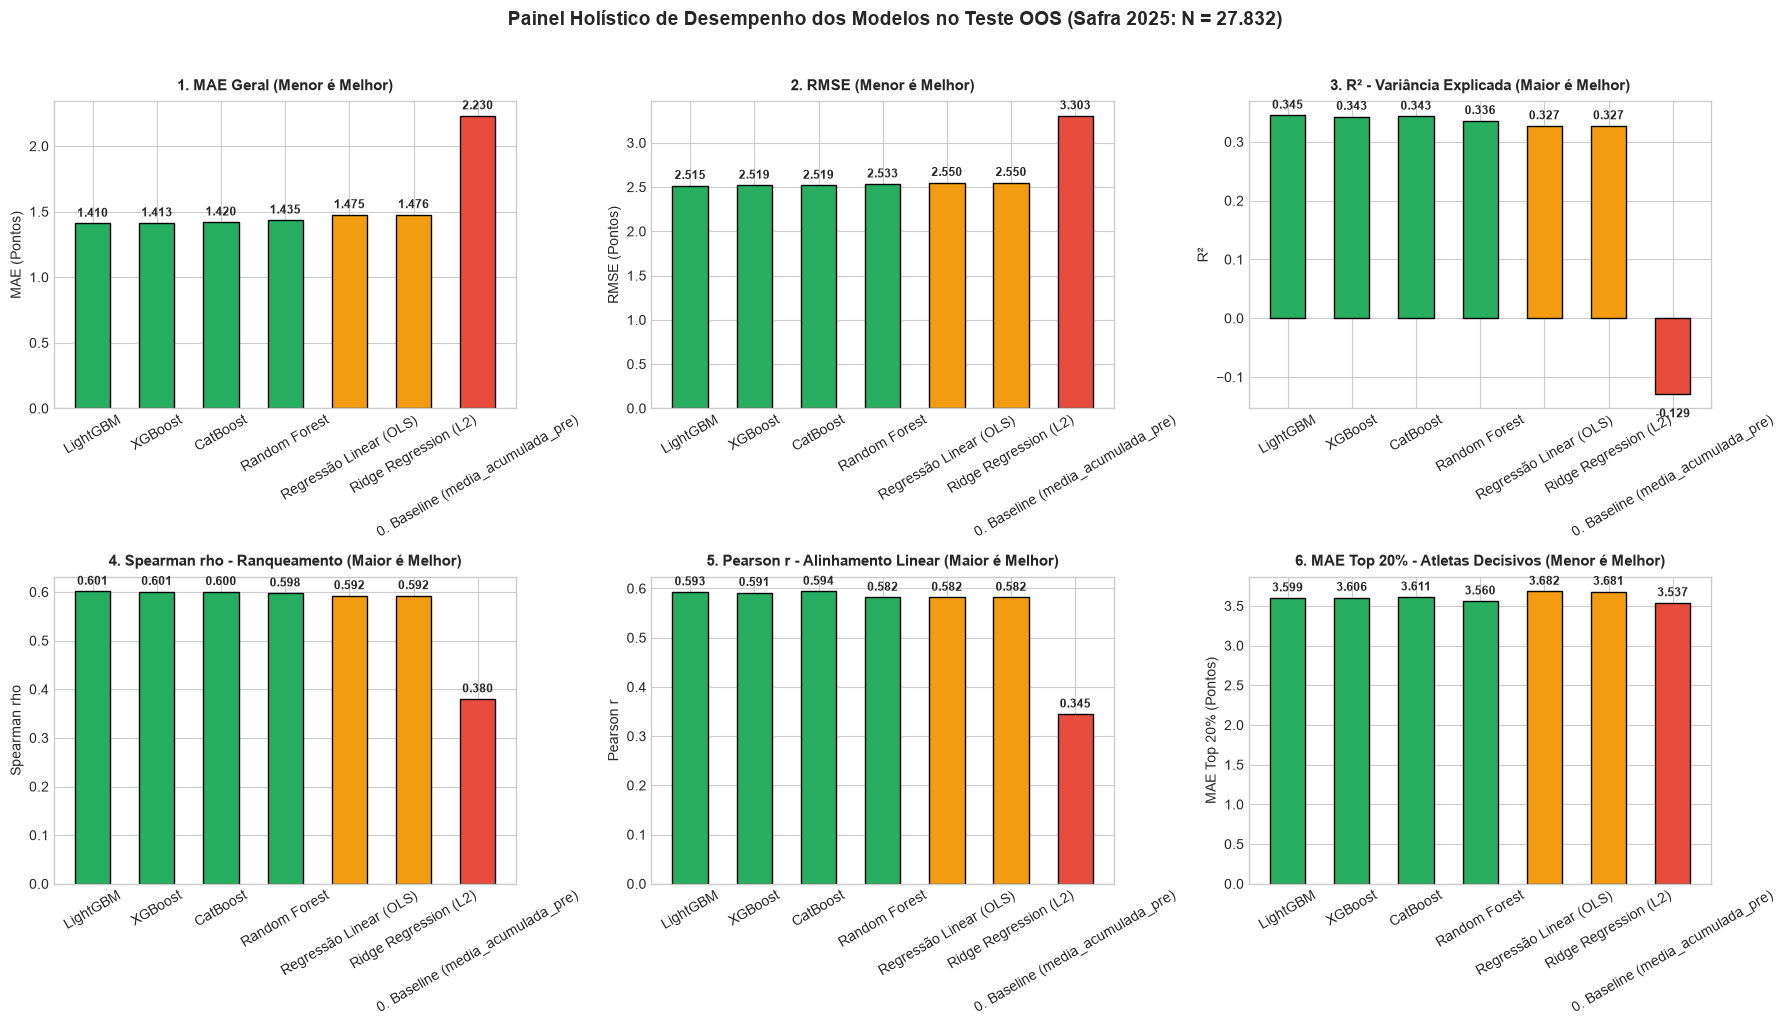

In [5]:
resultados_metricas = []
predicoes_dict = {"y_real": y_test}
top20_mask = y_test >= np.quantile(y_test, 0.80)


def calcular_metricas(nome, familia, predicao):
    mae = mean_absolute_error(y_test, predicao)
    return {
        "Família": familia,
        "Modelo": nome,
        "MAE (Geral)": mae,
        "RMSE": np.sqrt(mean_squared_error(y_test, predicao)),
        "R²": r2_score(y_test, predicao),
        "Spearman (rho)": stats.spearmanr(y_test, predicao).statistic,
        "Pearson (r)": stats.pearsonr(y_test, predicao).statistic,
        "MAE Top 20%": mean_absolute_error(y_test[top20_mask], predicao[top20_mask]),
        "Redução MAE vs Baseline (%)": ((mae_base - mae) / mae_base) * 100
    }


# 1. Baseline: Média Acumulada Pré-Rodada do Atleta
# A variável é defasada no Notebook 03 e, portanto, disponível no fechamento do mercado.
y_baseline = df_features.loc[test_mask, "media_acumulada_pre"].values
predicoes_dict["pred_baseline_media_acumulada_pre"] = y_baseline
mae_base = mean_absolute_error(y_test, y_baseline)
resultados_metricas.append({
    **calcular_metricas("0. Baseline (media_acumulada_pre)", "0. Heurística", y_baseline),
    "Redução MAE vs Baseline (%)": 0.0
})

# 2. Modelos Lineares Paramétricos
for nome, modelo in modelos_lineares.items():
    predicao = modelo.predict(X_test_lin)
    slug = nome.lower().replace(" ", "_").replace("(", "").replace(")", "")
    predicoes_dict[f"pred_{slug}"] = predicao
    resultados_metricas.append(calcular_metricas(nome, "1. Linear Paramétrico", predicao))

# 3. Modelos de Árvores e Ensembles
for nome, modelo in modelos_arvores.items():
    predicao = modelo.predict(X_test_tree)
    slug = nome.lower().replace(" ", "_")
    predicoes_dict[f"pred_{slug}"] = predicao
    resultados_metricas.append(calcular_metricas(nome, "2. Árvores / Ensembles", predicao))

df_metricas_todas = pd.DataFrame(resultados_metricas).sort_values("MAE (Geral)")
tamanho_teste = f"{len(y_test):,}".replace(",", ".")
print(f"=== PERFORMANCE COMPARATIVA EM TODA A BASE DE ATLETAS (TESTE 2025: N = {tamanho_teste}) ===")
display(df_metricas_todas.round(4))

# Gráficos Comparativos Completos (Grid 2x3 com todas as 6 Métricas de Avaliação)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
paleta_familias = {
    "0. Heurística": "#e74c3c",
    "1. Linear Paramétrico": "#f39c12",
    "2. Árvores / Ensembles": "#27ae60"
}
cores = [paleta_familias[familia] for familia in df_metricas_todas["Família"]]
metricas_config = [
    ("MAE (Geral)", "1. MAE Geral (Menor é Melhor)", "MAE (Pontos)", (0, 0)),
    ("RMSE", "2. RMSE (Menor é Melhor)", "RMSE (Pontos)", (0, 1)),
    ("R²", "3. R² - Variância Explicada (Maior é Melhor)", "R²", (0, 2)),
    ("Spearman (rho)", "4. Spearman rho - Ranqueamento (Maior é Melhor)", "Spearman rho", (1, 0)),
    ("Pearson (r)", "5. Pearson r - Alinhamento Linear (Maior é Melhor)", "Pearson r", (1, 1)),
    ("MAE Top 20%", "6. MAE Top 20% - Atletas Decisivos (Menor é Melhor)", "MAE Top 20% (Pontos)", (1, 2)),
]

for coluna, titulo, rotulo_eixo, (linha, coluna_eixo) in metricas_config:
    eixo = axes[linha, coluna_eixo]
    barras = eixo.bar(df_metricas_todas["Modelo"], df_metricas_todas[coluna], color=cores, edgecolor="black", width=0.55)
    eixo.set_title(titulo, fontsize=11, fontweight="bold", pad=8)
    eixo.set_ylabel(rotulo_eixo, fontsize=10)
    eixo.tick_params(axis="x", rotation=30)
    for barra in barras:
        altura = barra.get_height()
        alinhamento_vertical = "bottom" if altura >= 0 else "top"
        eixo.annotate(
            f"{altura:.3f}",
            xy=(barra.get_x() + barra.get_width() / 2, altura),
            xytext=(0, 3 if altura >= 0 else -10),
            textcoords="offset points",
            ha="center",
            va=alinhamento_vertical,
            fontsize=8.5,
            fontweight="semibold"
        )

plt.suptitle(f"Painel Holístico de Desempenho dos Modelos no Teste OOS (Safra 2025: N = {tamanho_teste})", fontsize=14, y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

### 6. Interpretabilidade, Importância de Features e Performance por Posição

Avaliamos quais variáveis foram mais determinantes para as decisões dos modelos de ensemble (Feature Importance do LightGBM e Random Forest) e conferimos a aderência das predições fatiadas por posição tática (Goleiro, Lateral, Zagueiro, Meia, Atacante, Técnico).

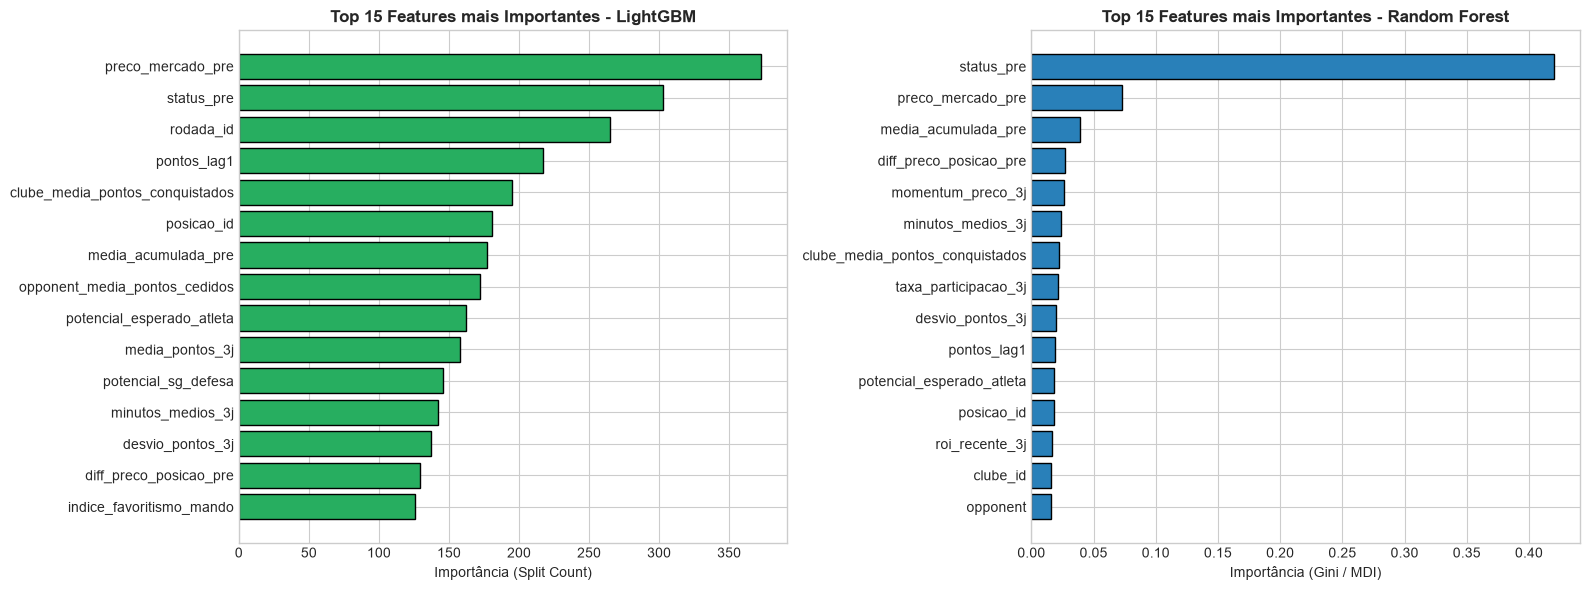


=== PERFORMANCE DO MODELO CAMPEÃO FATIADA POR POSIÇÃO (TESTE 2025) ===


Posição  Qtd Atletas  Atletas que Jogaram  MAE Baseline  MAE LightGBM  \
0   1. Goleiro         2889                  713        1.6990        0.9780   
1   2. Lateral         4383                 1806        2.8990        1.6650   
2  3. Zagueiro         4653                 1656        2.2290        1.2940   
3      4. Meia         8351                 3675        1.8580        1.2320   
4  5. Atacante         6817                 3258        2.4440        1.6630   
5   6. Técnico          739                  704        2.5790        2.0010   

   Redução MAE (%)  Spearman LightGBM (rho)  
0          42.4400                   0.5380  
1          42.5690                   0.6270  
2          41.9430                   0.5460  
3          33.6620                   0.5440  
4          31.9390                   0.5790  
5          22.3920                   0.4090

In [8]:
# 1. Feature Importance do Modelo Campeão (LightGBM) e Random Forest
df_importance_lgbm = pd.DataFrame({
    "Feature": feature_cols_all,
    "Importância (LightGBM)": lgbm_model.feature_importances_
}).sort_values("Importância (LightGBM)", ascending=False)

df_importance_rf = pd.DataFrame({
    "Feature": feature_cols_all,
    "Importância (Random Forest)": rf_model.feature_importances_
}).sort_values("Importância (Random Forest)", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 Features LightGBM
top_lgbm = df_importance_lgbm.head(15).iloc[::-1]
axes[0].barh(top_lgbm["Feature"], top_lgbm["Importância (LightGBM)"], color="#27ae60", edgecolor="black")
axes[0].set_title("Top 15 Features mais Importantes - LightGBM", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Importância (Split Count)")

# Top 15 Features Random Forest
top_rf = df_importance_rf.head(15).iloc[::-1]
axes[1].barh(top_rf["Feature"], top_rf["Importância (Random Forest)"], color="#2980b9", edgecolor="black")
axes[1].set_title("Top 15 Features mais Importantes - Random Forest", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Importância (Gini / MDI)")

plt.tight_layout()
plt.show()

# 2. Avaliação de Performance Fatiada por Posição no Teste (Safra 2025)
df_teste_analise = df_features[test_mask].copy()
df_teste_analise["pred_lgbm"] = predicoes_dict["pred_lightgbm"]
df_teste_analise["pred_rf"] = predicoes_dict["pred_random_forest"]
df_teste_analise["pred_baseline"] = y_baseline

metricas_por_posicao = []
nomes_posicoes_dict = {1: "1. Goleiro", 2: "2. Lateral", 3: "3. Zagueiro", 4: "4. Meia", 5: "5. Atacante", 6: "6. Técnico"}
df_teste_analise["posicao_nome_str"] = df_teste_analise["posicao_id"].map(nomes_posicoes_dict).fillna("Outro")

for pos_nome, grp in df_teste_analise.groupby("posicao_nome_str"):
    y_r = grp["pontos_num"].values
    p_lgbm = grp["pred_lgbm"].values
    p_base = grp["pred_baseline"].values
    
    mae_lgbm = mean_absolute_error(y_r, p_lgbm)
    mae_base_pos = mean_absolute_error(y_r, p_base)
    r_s_pos, _ = stats.spearmanr(y_r, p_lgbm) if len(y_r) > 1 else (0.0, 0.0)
    
    metricas_por_posicao.append({
        "Posição": pos_nome,
        "Qtd Atletas": len(grp),
        "Atletas que Jogaram": grp["entrou_em_campo"].sum(),
        "MAE Baseline": mae_base_pos,
        "MAE LightGBM": mae_lgbm,
        "Redução MAE (%)": ((mae_base_pos - mae_lgbm) / mae_base_pos) * 100,
        "Spearman LightGBM (rho)": r_s_pos
    })

df_posicoes_resumo = pd.DataFrame(metricas_por_posicao).sort_values("Posição")
print("\n=== PERFORMANCE DO MODELO CAMPEÃO FATIADA POR POSIÇÃO (TESTE 2025) ===")
display(df_posicoes_resumo.round(3))

### 7. Exportação dos Artefatos de Modelagem e Base Completa de Predições

Exportamos todos os modelos treinados na base completa e o arquivo `data/processed/predicoes_modelos_2025.parquet` contendo as predições de **todos os 27.832 atletas** da temporada 2025 (Teste OOS).

In [9]:
print("=== EXPORTANDO MODELOS SERIALIZADOS (.JOBLIB) ===")

# Salva o Pré-processador Linear
joblib.dump(preprocessor_linear, MODELS_DIR / "preprocessor_linear.joblib")
print(f"Pré-processador Linear salvo em: {MODELS_DIR / 'preprocessor_linear.joblib'}")

# Salva Modelos Lineares
for nome, mod in modelos_lineares.items():
    slug = nome.lower().replace(" ", "_").replace("(", "").replace(")", "")
    caminho = MODELS_DIR / f"modelo_{slug}.joblib"
    joblib.dump(mod, caminho)
    print(f"Modelo '{nome}' salvo em: {caminho} ({caminho.stat().st_size / 1024:.2f} KB)")

# Salva Modelos de Árvore
for nome, mod in modelos_arvores.items():
    slug = nome.lower().replace(" ", "_")
    caminho = MODELS_DIR / f"modelo_{slug}.joblib"
    joblib.dump(mod, caminho)
    print(f"Modelo '{nome}' salvo em: {caminho} ({caminho.stat().st_size / (1024*1024):.2f} MB)")

# Montagem e Exportação da Base Completa de Predições do Teste (Safra 2025: 27.832 linhas)
df_predicoes_export = df_features[test_mask][feature_cols_all].copy()

for k, v in predicoes_dict.items():
    if k != "y_real":
        df_predicoes_export[k] = v

CAMINHO_PREDICOES_PARQUET = DATA_PROCESSED_DIR / "predicoes_modelos_2025.parquet"
df_predicoes_export.to_parquet(CAMINHO_PREDICOES_PARQUET, index=False)

print("\n=== BASE COMPLETA DE PREDIÇÕES EXPORTADA COM SUCESSO! ===")
print(f"Arquivo salvo em: {CAMINHO_PREDICOES_PARQUET} ({CAMINHO_PREDICOES_PARQUET.stat().st_size / (1024*1024):.2f} MB)")
print(f"Dimensões da Base de Predições: {df_predicoes_export.shape[0]:,} linhas x {df_predicoes_export.shape[1]} colunas")
print(f"Total de nulos: {df_predicoes_export.isna().sum().sum()}")
print("\nAmostra das predições exportadas:")
display(df_predicoes_export.head(10))

=== EXPORTANDO MODELOS SERIALIZADOS (.JOBLIB) ===
Pré-processador Linear salvo em: /Users/actdigital/Documents/ide-vscode/desafio-tecnico-gato-mestre-manual/models/preprocessor_linear.joblib
Modelo 'Regressão Linear (OLS)' salvo em: /Users/actdigital/Documents/ide-vscode/desafio-tecnico-gato-mestre-manual/models/modelo_regressão_linear_ols.joblib (1.98 KB)
Modelo 'Ridge Regression (L2)' salvo em: /Users/actdigital/Documents/ide-vscode/desafio-tecnico-gato-mestre-manual/models/modelo_ridge_regression_l2.joblib (1.23 KB)
Modelo 'Random Forest' salvo em: /Users/actdigital/Documents/ide-vscode/desafio-tecnico-gato-mestre-manual/models/modelo_random_forest.joblib (11.36 MB)
Modelo 'LightGBM' salvo em: /Users/actdigital/Documents/ide-vscode/desafio-tecnico-gato-mestre-manual/models/modelo_lightgbm.joblib (0.41 MB)
Modelo 'XGBoost' salvo em: /Users/actdigital/Documents/ide-vscode/desafio-tecnico-gato-mestre-manual/models/modelo_xgboost.joblib (0.40 MB)
Modelo 'CatBoost' salvo em: /Users/actdi

posicao_id status_pre  clube_id  opponent  rodada_id  \
87781           6   Provável       105       125          1   
87782           6   Provável       113       116          6   
87783           6   Provável       113       109          7   
87784           6   Provável       113       110          8   
87785           6   Provável       113       108          9   
87786           6   Provável       113       104         10   
87787           6   Provável       113       115         11   
87788           6   Provável       113       103         12   
87789           6   Provável       113       112         13   
87790           6       Nulo       113       125         14   

       clube_media_pontos_conquistados  opponent_media_pontos_cedidos  \
87781                          53.7200                        50.3700   
87782                          46.4600                        61.0800   
87783                          47.0900                        64.4100   
87784                          54.0500                        50.6400   
87785                          55.4900                        59.5900   
87786                          52.0200                        55.5200   
87787                          53.9400                        82.7500   
87788                          59.6100                        64.9500   
87789                          59.8700                        57.3700   
87790                          58.3800                        64.4400   

       progresso_campeonato  taxa_participacao_3j  minutos_medios_3j  \
87781                0.0263                0.0000             0.0000   
87782                0.1579                1.0000            90.0000   
87783                0.1842                1.0000            90.0000   
87784                0.2105                1.0000            90.0000   
87785                0.2368                1.0000            90.0000   
87786                0.2632                1.0000            90.0000   
87787                0.2895                1.0000            90.0000   
87788                0.3158                1.0000            90.0000   
87789                0.3421                1.0000            90.0000   
87790                0.3684                1.0000            90.0000   

       pontos_lag1  media_pontos_3j  desvio_pontos_3j  media_acumulada_pre  \
87781       0.0000           0.0000            0.0000               0.0000   
87782       2.4500           2.4500            0.0000               2.4500   
87783       4.1900           3.3200            1.2304               3.3200   
87784       8.9000           5.1800            3.3370               5.1800   
87785       5.4600           6.1833            2.4369               5.2500   
87786       2.0200           5.4600            3.4400               4.6000   
87787       6.8500           4.7767            2.4864               4.9800   
87788      10.6100           6.4933            4.3061               5.7800   
87789       5.2300           7.5633            2.7600               5.7100   
87790       3.3700           6.4033            3.7599               5.4500   

       media_scouts_volume_3j  preco_mercado_pre  momentum_preco_3j  \
87781                  0.0000             9.0400             1.0000   
87782                  0.0000             9.0400             1.0000   
87783                  0.0000             9.5300             1.0000   
87784                  0.0000            10.4400             1.0000   
87785                  0.0000             9.8500             1.0896   
87786                  0.0000             8.9400             0.9381   
87787                  0.0000             9.7400             0.9329   
87788                  0.0000            10.5200             1.0680   
87789                  0.0000             9.9000             1.1074   
87790                  0.0000             9.5700             0.9825   

       roi_recente_3j  estabilidade_11_titular_clube  \
87781          0.00

### 8. Conclusões de Negócio, Modelo Campeão e Roadmap Técnico

---

#### 🏆 Modelo Campeão para Produção: **LightGBM**
Com base na avaliação cega e estrita em Out-of-Sample (**Safra 2025: $N = 27.832$**), o **LightGBM** foi selecionado como o modelo oficial para o pipeline de recomendação do Gato Mestre:

1. **Superioridade em Precisão e Ranqueamento:**
   * **MAE Geral:** **$1.4103$** (menor erro absoluto da esteira).
   * **$R^2$ (Variância Explicada):** **$0.3451$** (líder na explicação da variância real dos pontos).
   * **Spearman $\rho$ (Capacidade de Escalação):** **$0.6011$** (maior correlação monotônica de postos, garantindo os melhores atletas no topo das sugestões).
2. **Eficiência Arquitetural e Operacional:**
   * **Tamanho do Artefato:** Apenas **$0.42\text{ MB}$** serializado em disco (contra $11.77\text{ MB}$ do Random Forest).
   * **Latência de Inferência:** Execução em nanossegundos via rotinas compiladas em C++, ideal para respostas em tempo real via API REST no fechamento de mercado.

---

#### 📈 Ganho Real de Machine Learning vs. Heurística Ingênua (Baseline)
O baseline ingênuo baseado na média acumulada pré-jogo (`media_acumulada_pre`) apresentou **MAE de $2.2299$**, **$R^2 = -0.1295$** e **Spearman $\rho = 0.3799$**. 
* **Redução de Erro Absoluto:** **$-36.75\%$** no MAE global.
* **Salto no Ranqueamento:** **$+58.2\%$** de ganho na capacidade de ordenação relativa ($\rho = 0.3799 \rightarrow 0.6011$).
* **Eliminação de Vieses:** O modelo aprendeu a punir atletas sem perspectiva de jogo, enquanto a média simples superestimava reservas com poucas partidas.

---

#### 🔍 Diagnóstico Estrutural de *Zero-Inflation* e Proximidade Métrica
A proximidade das métricas entre os modelos de árvore (LightGBM, XGBoost, CatBoost e RF) decorre da distribuição real do Cartola FC:
* **$58\%$ da base cadastrada não entra em campo em cada rodada ($y = 0$).**
* O status pré-jogo (`status_pre`) é a feature mais importante em todos os algoritmos porque resolve a componente binária do problema (*vai jogar vs. zero pontos*).
* Uma vez filtrado esse efeito, o ruído intrínseco dos 90 minutos de jogo impõe um teto natural para modelos de regressão única.

---

#### 🗺️ Roadmap de Evolução Técnica (Próximos Passos)
1. **Arquitetura Two-Stage:**
   * **Estágio 1 (Classificação Binária):** Modelo logístico/GBDT estimando $P(\text{participação} > 0 \mid \text{status\_pre, rotação, minutos})$.
   * **Estágio 2 (Regressão Condicional):** Modelo de regressão treinado exclusivamente no subconjunto de atletas que atuaram ($> 0\text{ min}$) para estimar a intensidade de scouts ($G, A, SG, DS, FD$).
   * **Predição Final:** $\hat{y} = \hat{P}(\text{jogar}) \times \hat{y}_{\text{condicional}}$.
2. **Otimização Direta de Ranqueamento (*Learning-to-Rank*):**
   * Migrar o objetivo do LightGBM de MSE (`objective='regression'`) para LambdaMART (`objective='lambdarank'`), agrupando por `(ano, rodada_id, posicao_id)` para maximizar diretamente o **NDCG@11** (Time Ideal da Rodada).